<a href="https://colab.research.google.com/github/sayak395/Waveform_with_CNN/blob/Improvements/01726085_ML4_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Start of Project

<hr style="border:2px solid gray">

# Table of Contents <a id='index'></a>
1. [Exploring the Waveforms](#what)
2. [Designing the CNN](#design)
3. [Initial CNN architecture](#initial)
4. [Optimising the CNN depth](#conv)


<div style="background-color:#C2F5DD">

Before we start implementing a CNN it would be well worth the time to look at the waveforms more closely to identify features of importance, perhaps even Fourier Transform the data to get a feel. Then we can proceede to designing and training a neural network.

### Exploring the Waveforms <a id='what'></a>

<div style="background-color:#C2F5DD">

We can start off by straight away removing the first 200/250 points in all the waveforms because the recorded pulses begin at 250. This has a two-fold advantage:

1. This shortens the size of the dataset thus preventing any unncessary computation with the first few irrelevant points.

2. The removal of the first few points will prevent the CNN from attempting to learn features which are not relevant for the classification task.

In [2]:
pip install bayesian-optimization

In [3]:
from google.colab import drive
drive.mount('/content/drive') #getting the files preloaded to avoid time

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import torch

sns.set() #make plots prettier

# choose your preferred font size and style here for plots
plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'DejaVu Serif'

In [5]:
#Introducing seeds to ensure repeatable results.
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

In [6]:
path = 'drive/MyDrive/Data/'

In [7]:
# importing the datasets
xtrain = np.load(path+"x_train.npy")
ytrain = np.load(path+"y_train.npy")
xtest = np.load(path+"x_test.npy")
ytest = np.load(path+"y_test.npy")
print(xtrain.shape,xtest.shape)

(12302, 1000) (3076, 1000)


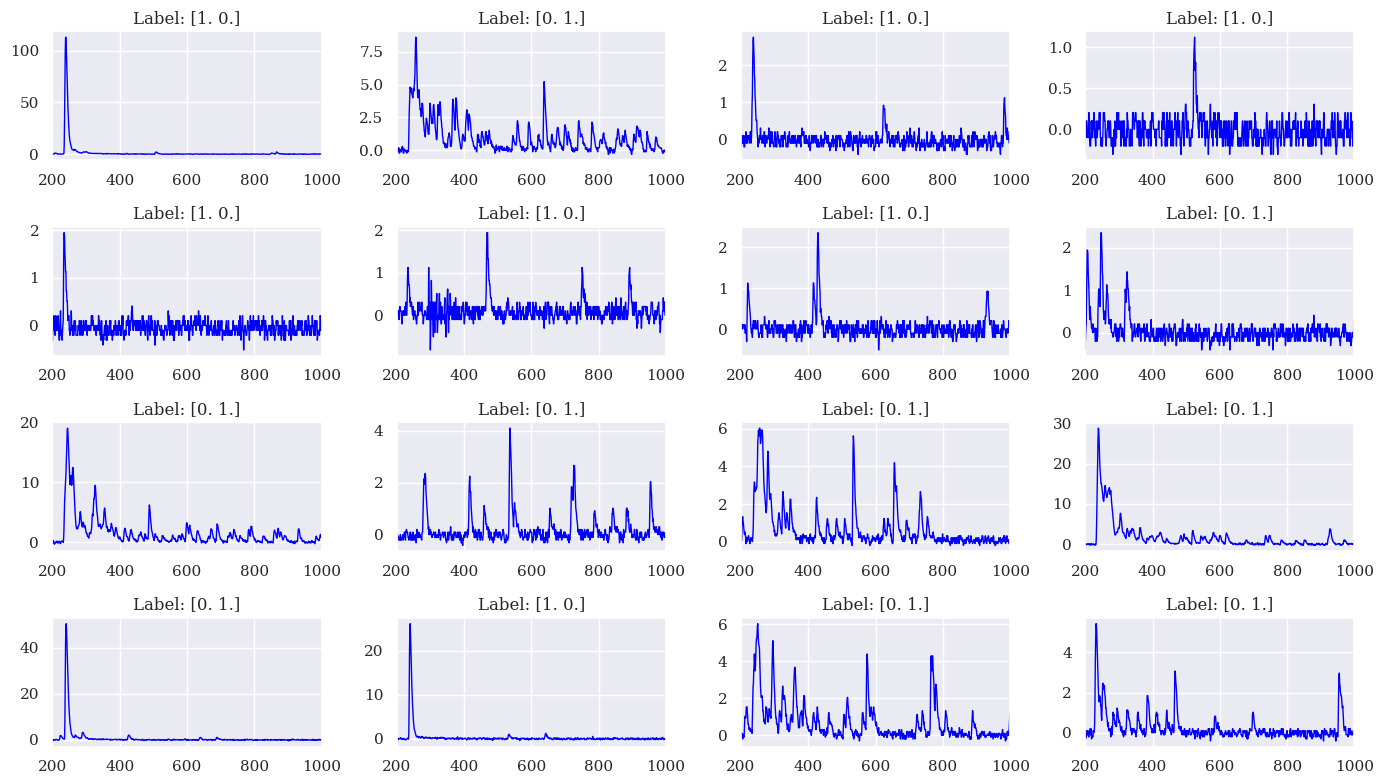

In [8]:
fig, ax = plt.subplots(4, 4, figsize=(14, 8))
ax = ax.flatten()
for i in range(0, 16):
    j = np.random.randint(0, len(xtrain))
    #print(j)
    ax[i].plot(xtrain[j],color='blue',lw=1)
    ax[i].set_title("Label: {}".format(ytrain[j]))
    ax[i].set_xlim(200., 1000) #used to zoom around trigger time
fig.tight_layout()

### Designing the CNN <a id='design'></a>

<div style="background-color:#C2F5DD">

To begin designing the network we can layout a basic architecture whereby we design a relatively small network to get a feel of how it performs. Later on we can begin by optimising the parameters and experimenting with the network architecture.

In [9]:
xtrain_torch = torch.tensor(xtrain).float() #transforming data to a tensor
ytrain_torch = torch.tensor(ytrain).float()
xtest_torch = torch.tensor(xtest).float()
ytest_torch = torch.tensor(ytest).float()

In [10]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(xtrain_torch, ytrain_torch)
test_dataset = TensorDataset(xtest_torch, ytest_torch)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True) #Loading data into a batch and use batch size of 64
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

<div style="background-color:#C2F5DD">

The following is a basic outline for the architecture of the CNN. So far, two convolutions have been added followed by some linear layers. A RELU activation function has been chosen because it returns non-zero gradients which is important for backpropagation and preventing dead neurons. However, at the end a sigmoid activation function has been used as this is a binary classification task and sigmoid returns either 0 or 1. The neurons at each layer and the pooling have been chosen arbitrarily and can be changed, but this is a good starting point to initially setup the network and see how good the CNN is at classifying the signal.

<div style="background-color:#C2F5DD">

Before we begin, a function has to be made to calculate the number of neurons outputted by the convolutional neural network layers to input into the linear layers.

In [11]:
def getNeurons(input_neurons, kernel, filter, stride=1, padding=0, dilation=1):

  input = torch.tensor([input_neurons], dtype=torch.float32).to(device) #make torch tensor for gpu

  output_size = ((input + 2 * padding - dilation * (kernel - 1) - 1) / stride) + 1
  return output_size.int()

In [12]:
#getNeurons(1000, kernel=5, filter=3) #check if function works

<div style="background-color:#C2F5DD">

The function used above was initially tried but due to error in computation another method was implemented whereby the shape was retrieved directly from a intial forward pass through the convolution layers. This had the disadvantage of computing the convolutional layers twice but on a gpu it did not make a very drastic change.

### Initial CNN architecture <a id='initial'></a>

In [13]:
import torch.nn as nn
import torch.nn.functional as F

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv1d(1, 64, 5)
        self.pool = nn.MaxPool1d(3)
        self.conv2 = nn.Conv1d(64, 128, 5)

        #output_size = getNeurons(1000, self.conv1.kernel_size[0], self.conv1.stride[0], self.conv1.padding[0], self.conv1.dilation[0])
        #output_size = getNeurons(output_size, self.pool.kernel_size, self.pool.stride, self.pool.padding, self.pool.dilation)
        #output_size = getNeurons(output_size, self.conv2.kernel_size[0], self.conv2.stride[0], self.conv2.padding[0], self.conv2.dilation[0])
        #output_size = getNeurons(output_size, self.pool.kernel_size, self.pool.stride, self.pool.padding, self.pool.dilation)
        #print(output_size)

        x = torch.randn(1, 1, 1000)
        output_shape = self.dummy_forward(x).size(-1)

        self.fc1 = nn.Linear(128 * output_shape, 128)
        self.fc2 = nn.Linear(128, 10)
        self.fc3 = nn.Linear(10, 1)

    def dummy_forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        return x

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.sigmoid(self.fc3(x))
        return x


In [14]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu") #check GPU acceleration
net = Net().to(device) #initialise the network
print(f'Device being used is: {device}')

Device being used is: cuda:0


<div style="background-color:#C2F5DD">

The loss function used here was the Binary Cross Entropy loss, which is the most commonly used one for binary classification problems which measures the loss between the target and the input probabilities. This loss function was preferred over Cross Entropy Loss which is more popular for multi-class classification problems. Again, the parameters of the SGD algorithm can be adjusted later on but for now some arbitrary but sensible values have been chosen.

The EarlyStopping class below is defined such that the training is stopped when the loss does not improve after a pre-defined number of epochs. This is done so that the model does not overfit the training data because the non-decreasing loss would imply that the model is memorising the training data rather than learning from it. Early stopping also has the added benefit of saving computational resources by preventing training of an overfit model.

In [15]:
class EarlyStopping:
    """Early stops the training if validation loss doesn't improve after a given patience period."""
    def __init__(self, patience=7, verbose=False, delta=0):
        """
        Args:
            patience (int): How long to wait after the last time validation loss improved.
                            Default: 7
            verbose (bool): If True, prints a message for each validation loss improvement.
                            Default: False
            delta (float): Minimum change in the monitored quantity to qualify as an improvement.
                           Default: 0
        """
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = float('inf')
        self.delta = delta

    def __call__(self, val_loss, model):
        score = -val_loss

        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.verbose:
                print(f'Early Stopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        '''Saves the model when validation loss decreases.'''

        if self.verbose:
            print(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}).  Saving model ...')
        torch.save(model.state_dict(), 'checkpoint.pt')
        self.val_loss_min = val_loss


In [16]:
#NEW TRAIN FUNCTION

import torch.optim as optim
from torch.nn import BCELoss

def train(model, train_loader=train_loader, val_loader=test_loader, max_epoch=10, momentum=0.9, lr=0.01, patience=7):

    """
    Trains a neural network model using the provided training and validation data loaders,
    employing early stopping to mitigate overfitting.

    Parameters:
    - model (torch.nn.Module): The neural network model to train.
    - train_loader (torch.utils.data.DataLoader): DataLoader for training data.
    - val_loader (torch.utils.data.DataLoader): DataLoader for validation data.
    - max_epoch (int, optional): Maximum number of epochs for training. Default is 10.
    - momentum (float, optional): Momentum factor for SGD optimizer. Default is 0.9.
    - lr (float, optional): Learning rate for the optimizer. Default is 0.01.
    - patience (int, optional): Patience for early stopping. Default is 7.

    Returns:
    - list: List of average training losses per epoch.
    - list: List of training accuracy percentages per epoch.
    - list: List of average validation losses per epoch.
    - list: List of validation accuracy percentages per epoch.
    """

    criterion = BCELoss()
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=momentum)
    early_stopping = EarlyStopping(patience=patience, verbose=True)

    model.train()  # Set model to training mode
    model.to(device)

    epoch_loss = []
    epoch_acc = []
    val_loss_list = []
    val_acc_list = []

    for epoch in range(max_epoch):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for data in train_loader:
            inputs, labels = data
            inputs = inputs.unsqueeze(1)  # add channel column
            labels = labels[:, 0].unsqueeze(1)  # only use one column

            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            predicted = torch.where(outputs > 0.5, torch.tensor(1.0, device=device), torch.tensor(0.0, device=device))
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        epoch_loss.append(running_loss / len(train_loader))
        epoch_acc.append(100 * correct / total)

        # Validation phase
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        model.eval()  # Set model to evaluation mode

        with torch.no_grad():
            for data in val_loader:
                inputs, labels = data
                inputs = inputs.unsqueeze(1)
                labels = labels[:, 0].unsqueeze(1)
                inputs, labels = inputs.to(device), labels.to(device) #gpu
                outputs = model(inputs)
                val_loss += criterion(outputs, labels).item()

                #Doing prediction
                val_predicted = torch.where(outputs > 0.5, torch.tensor(1.0, device=device), torch.tensor(0.0, device=device))
                val_total += labels.size(0)
                val_correct += (val_predicted == labels).sum().item()


        val_acc = 100 * val_correct / val_total #calculate loss and accurancy
        val_loss /= len(val_loader)


        val_loss_list.append(val_loss)
        val_acc_list.append(val_acc)

        print(f'Epoch {epoch+1}, Train Loss: {running_loss / len(train_loader):.4f}, Val Loss: {val_loss:.4f}')

        # Early Stopping to precent overfitting
        early_stopping(val_loss, model)
        if early_stopping.early_stop:
            print("Early stopping triggered")
            break

    # Load the best model
    #model.load_state_dict(torch.load('checkpoint.pt'))
    return epoch_loss, epoch_acc, val_loss_list, val_acc_list


In [17]:
tl, ta, vl, va = train(model=net)

Epoch 1, Train Loss: 0.2812, Val Loss: 0.1137
Validation loss decreased (inf --> 0.113668).  Saving model ...
Epoch 2, Train Loss: 0.1538, Val Loss: 0.0782
Validation loss decreased (0.113668 --> 0.078209).  Saving model ...
Epoch 3, Train Loss: 0.0875, Val Loss: 0.0646
Validation loss decreased (0.078209 --> 0.064632).  Saving model ...
Epoch 4, Train Loss: 0.0704, Val Loss: 0.0800
Early Stopping counter: 1 out of 7
Epoch 5, Train Loss: 0.0681, Val Loss: 0.0673
Early Stopping counter: 2 out of 7
Epoch 6, Train Loss: 0.0647, Val Loss: 0.0629
Validation loss decreased (0.064632 --> 0.062903).  Saving model ...
Epoch 7, Train Loss: 0.0629, Val Loss: 0.0584
Validation loss decreased (0.062903 --> 0.058436).  Saving model ...
Epoch 8, Train Loss: 0.0607, Val Loss: 0.0589
Early Stopping counter: 1 out of 7
Epoch 9, Train Loss: 0.0596, Val Loss: 0.0591
Early Stopping counter: 2 out of 7
Epoch 10, Train Loss: 0.0585, Val Loss: 0.0598
Early Stopping counter: 3 out of 7


# <div style="background-color:#C2F5DD">

Now that a basic CNN has been trained, it would be instructive to examine how this CNN performs on the entire dataset.

In [18]:
def test(model, test_loader=test_loader):
    """
    Evaluates a neural network model using a provided test data loader.

    Parameters:
    - model (torch.nn.Module): The neural network model to be evaluated.
    - test_loader (torch.utils.data.DataLoader): DataLoader for test data.

    Returns:
    - float: Average loss over the test dataset.
    - float: Overall accuracy percentage across the test dataset.
    - list: Collected labels from the test dataset.
    - list: Model predictions corresponding to the test labels.
    """


    criterion = nn.BCELoss()
    model.eval()
    model.to(device)

    all_labels = []
    all_predictions = []

    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for data in test_loader:
            inputs, labels = data
            inputs = inputs.unsqueeze(1)
            labels = labels[:, 0].unsqueeze(1)

            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item()

            predicted = torch.where(outputs > 0.5, torch.tensor(1.0, device=device), torch.tensor(0.0, device=device))
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(outputs.cpu().numpy())

    return total_loss / len(test_loader), 100 * correct / total, all_labels, all_predictions


In [19]:
l, a, _, _ = test(model=net)

Below we have defined a function to plot the training against the testing loss. The training loss will be important to identify whether the model generalises well whilst the validation loss will verify if the model is the overfitting or underfitting.

In [20]:
def plot_metrics(train_loss, val_loss, train_acc, val_acc, title='Training vs. Validation Metrics'):
    """
    Plots the training and validation loss and accuracy.

    Args:
    train_loss (list): List of training losses.
    val_loss (list): List of validation losses.
    train_acc (list): List of training accuracies.
    val_acc (list): List of validation accuracies.
    title (str): Title of the plot.
    """
    epochs = range(1, len(train_loss) + 1)

    plt.figure(figsize=(14, 5))

    # Plotting training and validation losses
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_loss, 'bo-', label='Training Loss')
    plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # Plotting training and validation accuracies
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_acc, 'bo-', label='Training Accuracy')
    plt.plot(epochs, val_acc, 'ro-', label='Validation Accuracy')
    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.show()


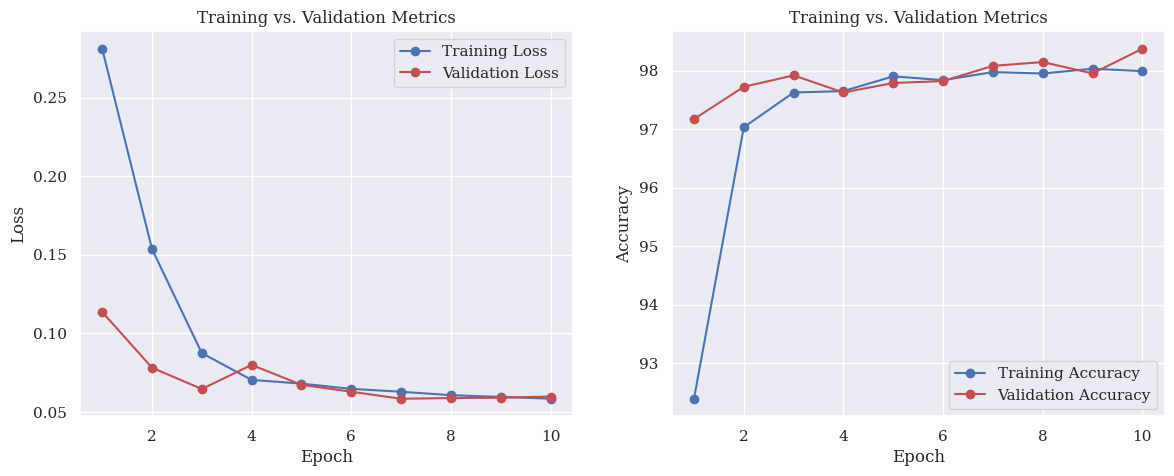

In [21]:
plot_metrics(tl, vl, ta, va)

<div style="background-color:#C2F5DD">

Above the training and validation losses and accuracies have been plotted. This is important because the validation loss should be decreasing as well as the training loss which implies good generalisation of the neural network to the data. If the validation loss is above the training loss then that indicates overfitting. The early stopping is introduced to combat this overfitting.


<div style="background-color:#C2F5DD">

The accuracy is good but of course the architecture of the neural network can be improved massively. Firstly, we can experiment with number of neurons in each layer and the depth of the network. We can try and optimise the SGD algorithm parameters and the number of passes through the data. Initially, lets begin by attempting to adjust the CNN by changing the convultion layers, the size of the kernel and the adjusting the neurons and depth in the linear layers. However, caution has to be maintained with dead neurons which have a gradient close to 0 so they don't train well.

Now let us begin by improving the architecture of the network such as the number of neurons, the layers, the kernel sizes etc. To simplify the optimisation we can attempt to optimise the linear and convolutional part separately. This is an acceptable approach because the purpose of the convolutional section is to identify features in the waveform and process the image data. The actual classification is done by the linear section so it okay to optimise the two parts seperately as they are serving a different purpose.

In [22]:
class Net_improved(nn.Module):
    def __init__(self, num_convolutional_layers=4, kernel_size=2, padding=0,
                 stride=1, dilation=1, pool_size=2):
        super().__init__()

        self.kernel_size = kernel_size

        self.conv_layers = [] #store layers


        in_channels = 1 #initial input of waveform
        out_channels = 64


        for layer_idx in range(num_convolutional_layers):

          self.conv_layers.append(nn.Conv1d(in_channels, out_channels, kernel_size,
                                    stride, padding, dilation))
          self.conv_layers.append(nn.ReLU())
          self.conv_layers.append(nn.MaxPool1d(pool_size)) # Using a fixed pool size for simplicity

          in_channels = out_channels
          out_channels = out_channels * 2  # Double the output channels for the next layer


        self.conv_layers = nn.Sequential(*self.conv_layers)

        x = torch.randn(1, 1, 1000)
        output_shape = self.dummy_forward(x).size(-1)

        self.linear_layers = nn.Sequential( #manually adding linear layers

        nn.Linear(output_shape, 128),
        nn.ReLU(),
        nn.Linear(128, 10),
        nn.ReLU(),
        nn.Linear(10, 1),
        nn.Sigmoid()
        )

        self.linear_layers = nn.Sequential(*self.linear_layers)

    def dummy_forward(self, x): #calculating shape after convolution
      with torch.no_grad():
        x = self.conv_layers(x)
        x = torch.flatten(x, 1)
        return x


    def forward(self, x):
      x = self.conv_layers(x)
      x = torch.flatten(x, 1)
      x = self.linear_layers(x)
      return x




In [23]:
new_net = Net_improved() #trial to see if code works

In [24]:
print(new_net) #check if model has been created properly

Net_improved(
  (conv_layers): Sequential(
    (0): Conv1d(1, 64, kernel_size=(2,), stride=(1,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv1d(64, 128, kernel_size=(2,), stride=(1,))
    (4): ReLU()
    (5): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv1d(128, 256, kernel_size=(2,), stride=(1,))
    (7): ReLU()
    (8): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv1d(256, 512, kernel_size=(2,), stride=(1,))
    (10): ReLU()
    (11): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (linear_layers): Sequential(
    (0): Linear(in_features=31232, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=10, bias=True)
    (3): ReLU()
    (4): Linear(in_features=10, out_features=1, bias=True)
    (5): Sigmoid()
  )
)


#### Optimising convolution network depth <a id='conv depth'></a>

Optimising depth...:   0%|          | 0/8 [00:00<?, ?it/s]

Epoch 1, Train Loss: 0.2966, Val Loss: 0.1605
Validation loss decreased (inf --> 0.160506).  Saving model ...
Epoch 2, Train Loss: 0.2557, Val Loss: 0.2981
Early Stopping counter: 1 out of 7
Epoch 3, Train Loss: 0.3539, Val Loss: 0.5587
Early Stopping counter: 2 out of 7
Epoch 4, Train Loss: 0.1497, Val Loss: 0.0970
Validation loss decreased (0.160506 --> 0.096985).  Saving model ...
Epoch 5, Train Loss: 0.0988, Val Loss: 0.0921
Validation loss decreased (0.096985 --> 0.092093).  Saving model ...
Epoch 6, Train Loss: 0.0926, Val Loss: 0.0926
Early Stopping counter: 1 out of 7
Epoch 7, Train Loss: 0.0896, Val Loss: 0.0939
Early Stopping counter: 2 out of 7
Epoch 8, Train Loss: 0.0873, Val Loss: 0.0906
Validation loss decreased (0.092093 --> 0.090630).  Saving model ...
Epoch 9, Train Loss: 0.0847, Val Loss: 0.0908
Early Stopping counter: 1 out of 7


Optimising depth...:  12%|█▎        | 1/8 [00:03<00:24,  3.47s/it]

Epoch 10, Train Loss: 0.0870, Val Loss: 0.0938
Early Stopping counter: 2 out of 7
Epoch 1, Train Loss: 0.2253, Val Loss: 0.2663
Validation loss decreased (inf --> 0.266317).  Saving model ...
Epoch 2, Train Loss: 0.1349, Val Loss: 0.1099
Validation loss decreased (0.266317 --> 0.109919).  Saving model ...
Epoch 3, Train Loss: 0.1070, Val Loss: 0.0879
Validation loss decreased (0.109919 --> 0.087945).  Saving model ...
Epoch 4, Train Loss: 0.1152, Val Loss: 0.2478
Early Stopping counter: 1 out of 7
Epoch 5, Train Loss: 0.0985, Val Loss: 0.0863
Validation loss decreased (0.087945 --> 0.086264).  Saving model ...
Epoch 6, Train Loss: 0.0810, Val Loss: 0.0698
Validation loss decreased (0.086264 --> 0.069818).  Saving model ...
Epoch 7, Train Loss: 0.0736, Val Loss: 0.0872
Early Stopping counter: 1 out of 7
Epoch 8, Train Loss: 0.0705, Val Loss: 0.2007
Early Stopping counter: 2 out of 7
Epoch 9, Train Loss: 0.1038, Val Loss: 0.0925
Early Stopping counter: 3 out of 7


Optimising depth...:  25%|██▌       | 2/8 [00:07<00:23,  4.00s/it]

...

Optimising depth...:  75%|███████▌  | 6/8 [00:36<00:14,  7.12s/it]

Epoch 10, Train Loss: 0.0502, Val Loss: 0.0471
Validation loss decreased (0.047716 --> 0.047108).  Saving model ...
Epoch 1, Train Loss: 0.6049, Val Loss: 0.3956
Validation loss decreased (inf --> 0.395588).  Saving model ...
Epoch 2, Train Loss: 0.3134, Val Loss: 0.1473
Validation loss decreased (0.395588 --> 0.147288).  Saving model ...
Epoch 3, Train Loss: 0.2232, Val Loss: 0.0850
Validation loss decreased (0.147288 --> 0.085047).  Saving model ...
Epoch 4, Train Loss: 0.1380, Val Loss: 0.0688
Validation loss decreased (0.085047 --> 0.068825).  Saving model ...
Epoch 5, Train Loss: 0.1465, Val Loss: 0.0760
Early Stopping counter: 1 out of 7
Epoch 6, Train Loss: 0.0897, Val Loss: 0.0617
Validation loss decreased (0.068825 --> 0.061697).  Saving model ...
Epoch 7, Train Loss: 0.1178, Val Loss: 0.0781
Early Stopping counter: 1 out of 7
Epoch 8, Train Loss: 0.1088, Val Loss: 0.0628
Early Stopping counter: 2 out of 7
Epoch 9, Train Loss: 0.0674, Val Loss: 0.0628
Early Stopping counter: 3

Optimising depth...:  88%|████████▊ | 7/8 [00:47<00:08,  8.51s/it]

Epoch 10, Train Loss: 0.0748, Val Loss: 0.0555
Validation loss decreased (0.061697 --> 0.055501).  Saving model ...
Epoch 1, Train Loss: 0.6888, Val Loss: 0.6670
Validation loss decreased (inf --> 0.666965).  Saving model ...
Epoch 2, Train Loss: 0.4664, Val Loss: 0.2287
Validation loss decreased (0.666965 --> 0.228714).  Saving model ...
Epoch 3, Train Loss: 0.2708, Val Loss: 0.1092
Validation loss decreased (0.228714 --> 0.109199).  Saving model ...
Epoch 4, Train Loss: 0.2284, Val Loss: 0.1313
Early Stopping counter: 1 out of 7
Epoch 5, Train Loss: 0.1159, Val Loss: 0.1004
Validation loss decreased (0.109199 --> 0.100379).  Saving model ...
Epoch 6, Train Loss: 0.1729, Val Loss: 0.0745
Validation loss decreased (0.100379 --> 0.074532).  Saving model ...
Epoch 7, Train Loss: 0.1150, Val Loss: 0.2173
Early Stopping counter: 1 out of 7
Epoch 8, Train Loss: 0.1137, Val Loss: 0.0980
Early Stopping counter: 2 out of 7
Epoch 9, Train Loss: 0.0979, Val Loss: 0.0705
Validation loss decreased

Optimising depth...: 100%|██████████| 8/8 [01:05<00:00,  8.13s/it]


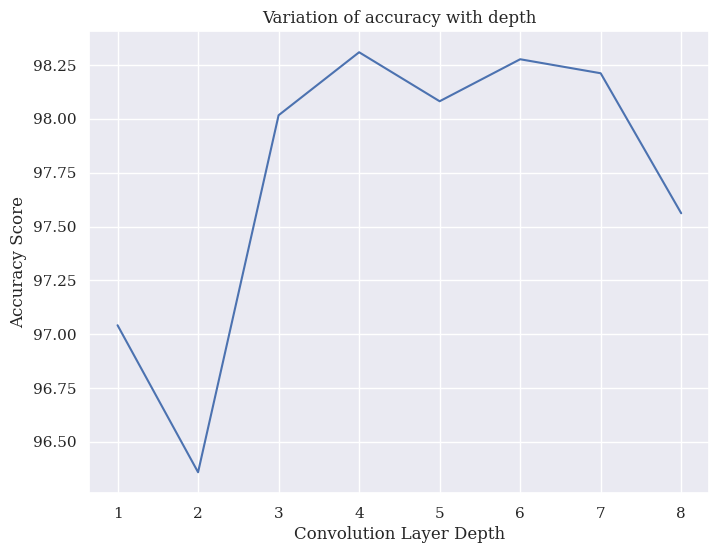

The best depth is 4


In [25]:
from tqdm import tqdm

train_loss = []
train_accuracy = []
test_loss = []
test_accuracy = []
depth = []

for i in tqdm(range(8), desc='Optimising depth...'): #investigate depth of network

  new_net = Net_improved(num_convolutional_layers=int(i)) #loadup network

  train_loss, train_acc, val_loss, val_acc = train(model=new_net)
  epoch_loss, epoch_acc, _, _ = test(model=new_net)
  train_loss.append(train_loss)
  train_accuracy.append(train_acc)
  test_loss.append(epoch_loss)
  test_accuracy.append(epoch_acc)
  depth.append(i + 1)

best_depth = np.argmax(test_accuracy) + 1
plt.title('Variation of accuracy with depth')
plt.xlabel('Convolution Layer Depth')
plt.ylabel('Accuracy Score')
plt.plot(depth, test_accuracy, label='accuracy')
plt.show()


print(f'The best depth is {best_depth}')

In [26]:
#plot_metrics(train_loss, test_loss, train_accuracy, test_accuracy) #check the metrics to ensure model is performing well

<div style="background-color:#C2F5DD">

After the optimisation has been run we can see that the optimal depth is 5 for the convolution layers. This physically makes sense because the input waveform is not a complicated image input thus too many layers should not be required to detect the features in the waveform image. However, for the architecture of the model, a depth of 3 was chosen to reduce the complexity of the model and using 5/6 layers only increases the accuracy by 0.1%. Using less layers also reduces the complexity of the network so the risk of overfitting is reduced.

Now the layers have been chosen, the kernel size, padding, dilation can be experimented with.

In [ ]:
min_matrix = np.zeros((2, 2, 4, 2))

for i in tqdm(range(2), desc='Minimising'): #optimising parameters
  for j in range(2):
    for k in range(4):
      for l in range(2):
        new_net = Net_improved(num_convolutional_layers=3, kernel_size=k+1, padding=i, dilation=j+1, pool_size=l+1)
        _, _, _, _ = train(model=new_net)
        epoch_loss, epoch_acc, _, _ = test(model=new_net)
        min_matrix[i, j, k, l] = epoch_acc

Minimising:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 1, Train Loss: 0.3866, Val Loss: 0.4017
Validation loss decreased (inf --> 0.401698).  Saving model ...
Epoch 2, Train Loss: 0.1212, Val Loss: 0.0614
Validation loss decreased (0.401698 --> 0.061444).  Saving model ...
Epoch 3, Train Loss: 0.0654, Val Loss: 0.0566
Validation loss decreased (0.061444 --> 0.056569).  Saving model ...
Epoch 4, Train Loss: 0.0600, Val Loss: 0.0586
Early Stopping counter: 1 out of 7
Epoch 5, Train Loss: 0.0541, Val Loss: 0.0509
Validation loss decreased (0.056569 --> 0.050860).  Saving model ...
Epoch 6, Train Loss: 0.0492, Val Loss: 0.0514
Early Stopping counter: 1 out of 7
Epoch 7, Train Loss: 0.0525, Val Loss: 0.0489
Validation loss decreased (0.050860 --> 0.048936).  Saving model ...
Epoch 8, Train Loss: 0.0474, Val Loss: 0.0538
Early Stopping counter: 1 out of 7
Epoch 9, Train Loss: 0.0461, Val Loss: 0.0484
Validation loss decreased (0.048936 --> 0.048387).  Saving model ...
Epoch 10, Train Loss: 0.0467, Val Loss: 0.0728
Early Stopping counter: 1

### Bayesian Optimisation <a id='bayes'></a>

<div style="background-color:#C2F5DD">

Bayesian optimisation is another method that can be used for hyperparameter tuning. Bayesian optimisation takes into account the previous parameters and thus optimises based on previous results. Bayesian optimisation usually works better than random grid search and is used in neural networks often because it has the advantage of finding optimal parameters more accurately than conventional grid search methods. Therefore, we can implement both approaches and compare them to see which yields better results in what time frame.

In [ ]:
pip install optuna

In [ ]:
import optuna

def objective(trial):

    #Setup grid for checking best parameters
    #num_convolutional_layers = trial.suggest_int('num_convolutional_layers', 1, 5)
    kernel_size = trial.suggest_int('kernel_size', 1, 3)
    padding = trial.suggest_int('padding', 0, 1)
    dilation = trial.suggest_int('dilation', 1, 3)
    pool_size = trial.suggest_int('pool_size', 1, 2)

    bayes_model = Net_improved(num_convolutional_layers=3,
                         kernel_size=kernel_size, padding=padding, dilation=dilation, pool_size=pool_size)



    train_loss, train_acc, val_loss, val_acc = train(model=bayes_model)

    return -val_acc[-1]

In [ ]:
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=10) #use 10 trials which should be fine
print('')
print('')
print("Best parameters: ", study.best_params)
print("Best value (negative accuracy): ", study.best_value)


<div style="background-color:#C2F5DD">

The Bayesian optimisation method is much faster than the grid search method and returns the optimal parameters. Thus, it is the function which will be used for future parameter optimisation.

In [ ]:
best_padding = study.best_params['padding']
best_dilation = study.best_params['dilation']
best_kernel_size = study.best_params['kernel_size']
best_pool_size = study.best_params['pool_size']

In [ ]:
improved_net = Net_improved(num_convolutional_layers=3, kernel_size=best_kernel_size,
                            padding=best_padding, dilation=best_dilation,
                            pool_size=best_pool_size) #testing whether the optimisation made a difference

In [ ]:
training_loss, training_accuracy, validation_loss, validation_accuracy = train(model=improved_net, max_epoch=50) #running for longer epochs to really examine neural network

In [ ]:
plot_metrics(train_loss=training_loss, train_acc=training_accuracy, val_loss=validation_loss, val_acc=validation_accuracy)

<div style="background-color:#C2F5DD">

We can see now the model running for a longer time of 50 epochs. The training parameters can be optmised later such as the batch size or the learning rate/momentum for the SGD algorithm. The model seems to be perform well. The kernel size, pool size do not need to be adjusted exactly because they are only providing incremental changes to the accuracy, a rough consideration is good enough.

For parameters such as stride, pool size we would expect these parameters to be close to 0 or very small because the convolution layer is relatively shallow thus the number of channels should not get out of hand rapidly. The stride parameter was not used for this reason and implementing a stride usually results in a loss of feature information. Thus, given the shallow nature of the network, the stride parameter was ignored.

Now we can adjust the channels in the convolution layers.

In [ ]:
class better_CNN_net(nn.Module):

  def __init__(self, in_channel=32, mid_channel=64, out_channel=128, act_fn=nn.ReLU(),
               kernel_size = best_kernel_size, pool_size=best_pool_size,
               padding=best_padding, dilation=best_dilation):

    super().__init__()

    self.conv_layers = nn.Sequential(
        nn.Conv1d(1, in_channel, kernel_size=kernel_size,
                  padding=padding, dilation=dilation),
        act_fn,
        nn.MaxPool1d(pool_size),
        nn.Conv1d(in_channel, mid_channel, kernel_size=kernel_size,
                  padding=padding, dilation=dilation),
        act_fn,
        nn.MaxPool1d(pool_size),
        nn.Conv1d(mid_channel, out_channel, kernel_size=kernel_size,
                  padding=padding, dilation=dilation),
        act_fn,
        nn.MaxPool1d(pool_size)
    )

    self.conv_layers = nn.Sequential(*self.conv_layers)

    x = torch.randn(1, 1, 1000)
    output_shape = self.dummy_forward(x).size(-1)

    self.linear_layers = nn.Sequential(
        nn.Linear(output_shape, 128),
        nn.ReLU(),
        nn.Linear(128, 10),
        nn.ReLU(),
        nn.Linear(10, 1),
        nn.Sigmoid()
    )

    self.linear_layers = nn.Sequential(*self.linear_layers)

  def dummy_forward(self, x):
      with torch.no_grad():
        x = self.conv_layers(x)
        x = torch.flatten(x, 1)
        return x

  def forward(self, x):
      x = self.conv_layers(x)
      x = torch.flatten(x, 1)
      x = self.linear_layers(x)
      return x

In [ ]:
def optimise_channels(trial):
    in_channel = trial.suggest_categorical('in_channel', [16, 32, 64, 128, 256])
    mid_channel = trial.suggest_categorical('mid_channel', [32, 64, 128, 256, 512])
    out_channel = trial.suggest_categorical('out_channel', [64, 128, 256, 512, 1024])

    channel_model = better_CNN_net(in_channel=in_channel, mid_channel=mid_channel, out_channel=out_channel)

    train_loss, train_acc, val_loss, val_acc = train(model=channel_model)

    return -val_acc[-1]  # Optimize for the highest validation accuracy


In [ ]:
# Create a study for channel optimization
channel_study = optuna.create_study(direction='maximize')
channel_study.optimize(optimise_channels, n_trials=10)

print("Best channel parameters: ", channel_study.best_params)
print("Best validation accuracy: ", -channel_study.best_value)

In [ ]:
#Storing best parameters
best_in_channel = channel_study.best_params['in_channel']
best_mid_channel = channel_study.best_params['mid_channel']
best_out_channel = channel_study.best_params['out_channel']

<div style="background-color:#C2F5DD">

Finally the convolutional part has been fully optimised we can now turn our attention the the linear layers. The linear layers will have some additional consideration such as dead neurons. Care has to be taken to make sure too many neurons are not dead. This is where a droput layer can also be introduced which will deactivate some neurons on purpose which in turn will prevent overfitting during training.

 We can experiment using leakyReLU as an activation function which has a slight non-zero gradient for the negatives which prevents gradients being too close to 0.

### Optimisng the Linear Network

In [ ]:
#remaking new network architecture

class linear_CNN_net(nn.Module):

  def __init__(self, in_channel=best_in_channel, mid_channel=best_mid_channel, out_channel=best_out_channel, act_fn=nn.ReLU(),
               kernel_size = best_kernel_size, pool_size=best_pool_size,
               padding=best_padding, dilation=best_dilation, depth = 3):

    super().__init__()

    self.conv_layers = nn.Sequential(
        nn.Conv1d(1, in_channel, kernel_size=kernel_size,
                  padding=padding, dilation=dilation),
        act_fn,
        nn.MaxPool1d(pool_size),
        nn.Conv1d(in_channel, mid_channel, kernel_size=kernel_size,
                  padding=padding, dilation=dilation),
        act_fn,
        nn.MaxPool1d(pool_size),
        nn.Conv1d(mid_channel, out_channel, kernel_size=kernel_size,
                  padding=padding, dilation=dilation),
        act_fn,
        nn.MaxPool1d(pool_size)
    )

    self.conv_layers = nn.Sequential(*self.conv_layers)

    x = torch.randn(1, 1, 1000)
    output_shape = self.dummy_forward(x).size(-1)

    self.linear_layers = []

    neurons_in = output_shape
    neurons_out = 32

    for depth in range(depth-1):
      self.linear_layers.append(nn.Linear(neurons_in, neurons_out))
      self.linear_layers.append(act_fn)
      neurons_in = neurons_out
      neurons_out = neurons_out * 2

    self.linear_layers.append(nn.Linear(neurons_in, 1))
    self.linear_layers.append(nn.Sigmoid())
    self.linear_layers = nn.Sequential(*self.linear_layers)

  def dummy_forward(self, x):
      with torch.no_grad():
        x = self.conv_layers(x)
        x = torch.flatten(x, 1)
        return x

  def forward(self, x):
      x = self.conv_layers(x)
      x = torch.flatten(x, 1)
      x = self.linear_layers(x)
      return x

In [ ]:
total_accuracy = []
depth = []

for i in tqdm(range(8), desc='Optimising depth...'): #investigate depth of network

  new_net = linear_CNN_net(
    in_channel=best_in_channel,
    mid_channel=best_mid_channel,
    out_channel=best_out_channel,
    kernel_size=best_kernel_size,
    pool_size=best_pool_size,
    padding=best_padding,
    dilation=best_dilation,
    depth=i)

  _ = train(model=new_net)
  epoch_loss, epoch_acc, _, _ = test(model=new_net)
  total_accuracy.append(epoch_acc)
  depth.append(i + 1)

best_depth = np.argmax(total_accuracy) + 1
plt.title('Variation of accuracy with depth')
plt.xlabel('Linear Layer Depth')
plt.ylabel('Accuracy Score')
plt.plot(depth, total_accuracy, label='accuracy')
plt.show()


print(f'The best depth is {best_depth}')



<div style="background-color:#C2F5DD">

The linear layer depth does not seem to change the accuracy too drastically which probably indicates that the network arhcitecture is close to the optimal setting. Thus choosing a depth of 2 for the linear layers to simplify the model preventing the risk of overfitting associated with a deeper model whilst also reducing the computational cost associated with a larger network. A depth of 2 was chosen over 1 because that would allow no hidden layers to be chosen, in turn increasing the risk of underfitting the data.

At this point we can experiment with different loss functions such as leaky ReLU and droputs between layers to improve regualrisation during training and prevent overfitting.

In [ ]:
class final_CNN(nn.Module):
    def __init__(self, in_channel=best_in_channel, out_channel=best_out_channel,
                 act_fn=nn.ReLU(),
                 kernel_size=best_kernel_size,
                 pool_size=best_pool_size, padding=best_padding, dilation=best_dilation,
                 neurons = 128, dropout_rate=0.2):
        super().__init__()

        # Define the convolutional layers
        self.conv_layers = nn.Sequential(
            nn.Conv1d(1, in_channel, kernel_size=kernel_size, padding=padding, dilation=dilation),
            act_fn,
            nn.MaxPool1d(pool_size),
            nn.Conv1d(in_channel, out_channel, kernel_size=kernel_size, padding=padding, dilation=dilation),
            act_fn,
            nn.MaxPool1d(pool_size)
        )

        # Dummy input to determine the output size from the convolutional stack
        x = torch.randn(1, 1, 1000)
        output_shape = self.dummy_forward(x).size(-1)

        self.linear_layers = nn.Sequential(
            nn.Linear(output_shape, neurons),
            act_fn,
            nn.Dropout(dropout_rate),
            nn.Linear(neurons, 1),
            nn.Sigmoid(),
        )


        self.linear_layers = nn.Sequential(*self.linear_layers)

    def dummy_forward(self, x):
        with torch.no_grad():
            x = self.conv_layers(x)
            x = torch.flatten(x, 1)
            return x

    def forward(self, x):
        x = self.conv_layers(x)
        x = torch.flatten(x, 1)
        x = self.linear_layers(x)
        return x


Finally, the number of neurons can be optimised. To identify if the droputs/ leaky ReLU functions make a different or not we need to examine the training loss and see which one gives a smoother learning curve. This would be indicative of the model training well and generalising to the data.

In [ ]:
def objective(trial):
    neuron = trial.suggest_categorical('neurons', [16, 32, 64, 128, 256, 512, 1024])
    model = final_CNN(neurons=neuron)

    train_loss, train_acc, val_loss, val_acc = train(model=model)
    epoch_loss, epoch_acc, _, _ = test(model=model)
    return -epoch_acc

In [ ]:
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=30)

best_neurons = study.best_params['neurons']
best_acc = -study.best_value

print(f'The optimal number of neurons is {best_neurons} with an accuracy of {best_acc}')


In [ ]:
better_net = final_CNN(neurons=best_neurons, act_fn=nn.LeakyReLU()) #checking with leaky ReLU
train_loss, train_acc, val_loss, val_acc = train(model=better_net)
test_loss, test_acc, _, _ = test(model=better_net) #observe the accuracy
plot_metrics(train_loss, val_loss, train_acc, val_acc)

The last thing remaining is to optimise the learning parameters for the stochastic gradient desecent. This will ensure that the optimal parameters are found via SGD algorithm.

In [ ]:

learning_rates = np.linspace(0.001, 0.1, 10)  #custom range to optimise
momentums = np.linspace(0.1, 0.99, 10)


results = {}

best_val_acc = 0
best_lr = None
best_momentum = None

for lr in learning_rates:
    for momentum in momentums:
        train_loss, train_acc = train(model, train_loader, max_epoch=50, momentum=momentum, lr=lr)
        val_loss, val_acc, _, _ = test(model, test_loader)
        results[(lr, momentum)] = (train_loss, val_loss, train_acc, val_acc)
        print(f"LR: {lr}, Momentum: {momentum}, Val Acc: {val_acc}, Val Loss: {val_loss}")

best_params = max(results, key=lambda x: results[x][3])  # Based on validation accuracy
best_train_loss, best_val_loss, best_train_acc, best_val_acc = results[best_params]

print(f"Best Learning Rate: {best_params[0]}, Best Momentum: {best_params[1]}")
print(f"Validation Accuracy: {best_val_acc}, Validation Loss: {best_val_loss}")

# Plot the results for the best hyperparameters
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(range(1, 11), best_train_loss, label='Training Loss')
plt.plot(range(1, 11), best_val_loss, label='Validation Loss')
plt.title('Best Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, 11), best_train_acc, label='Training Accuracy')
plt.plot(range(1, 11), best_val_acc, label='Validation Accuracy')
plt.title('Best Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()


In [ ]:
best_momentum = best_params[1]
best_lr = best_params[0]

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d') #making 3d plot

learning_rates = np.linspace(0.001, 0.1, 10)
momentums = np.linspace(0.1, 0.99, 10)

X, Y = np.meshgrid(learning_rates, momentums)
Z = np.array([[results[(lr, mo)][3] for lr in learning_rates] for mo in momentums])

ax.plot_surface(X, Y, Z, cmap='viridis')

ax.set_xlabel('Learning Rate')
ax.set_ylabel('Momentum')
ax.set_zlabel('Validation Accuracy')

ax.set_title('3D plot of Accuracy vs. Learning Rate and Momentum')

plt.show()


Once the training parameters and the architecture of the network has been optimised. The classification task can now be performed. It would also be appropriate to plot the AUC score and display the ROC curve and compare this to the initial network to see if the optimisation has made a difference or not. The confusion matrix can be plotted as well to determine the how many false postives and false negatives there were.

In [ ]:
old_net = Net() #basic CNN made at start
optimised_net = final_CNN(in_channel=best_in_channel, out_channel=best_out_channel,
                 act_fn=nn.LeakyReLU(),
                 kernel_size=best_kernel_size,
                 pool_size=best_pool_size, padding=best_padding, dilation=best_dilation,
                 neurons = 128, dropout_rate=0.2) #CNN with optimised parameters

In [ ]:
#Training the old and the new model
old_train_loss, old_train_acc, _, _ = train(model=old_net, momentum=0.9,
                                      lr=0.01, max_epoch=50)

new_train_loss, new_train_acc, _, _ = train(model=optimised_net, momentum=best_momentum,
                                      lr=best_lr, max_epoch=50)


# Testing both models and collecting predictions and labels
old_test_loss, old_train_loss, old_labels, old_preds = test(old_net, test_loader)
new_train_loss, new_train_acc, new_labels, new_preds = test(optimised_net, test_loader)

In [ ]:
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay

# Calculate ROC curve and ROC area for each model
fpr_old, tpr_old, _ = roc_curve(old_labels, old_preds)
roc_auc_old = auc(fpr_old, tpr_old)

fpr_new, tpr_new, _ = roc_curve(new_labels, new_preds)
roc_auc_new = auc(fpr_new, tpr_new)

# Plot ROC curve
plt.figure()
plt.plot(fpr_old, tpr_old, color='blue', label='Old Net ROC curve (area = %0.2f)' % roc_auc_old)
plt.plot(fpr_new, tpr_new, color='green', label='Optimised Net ROC curve (area = %0.2f)' % roc_auc_new)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()


In [ ]:
# Convert probabilities to binary predictions
binary_old_preds = [1 if x > 0.5 else 0 for x in old_preds]
binary_new_preds = [1 if x > 0.5 else 0 for x in new_preds]

# Calculate confusion matrices
cm_old = confusion_matrix(old_labels, binary_old_preds)
cm_new = confusion_matrix(new_labels, binary_new_preds)

# Plot confusion matrix for old net
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_old)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Old Net')

# Plot confusion matrix for optimised net
plt.subplot(1, 2, 2)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_new)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Optimised Net')
plt.show()

# EXTENSION